In [946]:
import opendatasets as od
import os
import numpy as np 
import pandas as pd 
import matplotlib
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns

In [947]:
# dataset_url = 'https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/'
# od.download(dataset_url, force=True)
# os.listdir('weather-dataset-rattle-package')
data_dir = './weather-dataset-rattle-package/'

train_csv = data_dir + '/weatherAUS.csv'

dataframe = pd.read_csv(train_csv)

# pd.set_option('display.max_columns', 30)

# pd.set_option('display.max_rows', None)

# pd.set_option('display.max_colwidth', None)

In [948]:
dataframe.dropna(subset=['RainToday','RainTomorrow'],inplace=True)

In [949]:
dataframe.info()
raw_df = dataframe.copy()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

In [950]:
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (10,7)
matplotlib.rcParams['font.size'] = 14

In [951]:
px.scatter(dataframe,x='Humidity9am',y='Humidity3pm',color='RainToday')

In [952]:
px.scatter(dataframe,x='Humidity9am',y='Pressure9am',color='RainToday')

In [953]:
#Encoding the non-numeric columns
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore')
input_columns = raw_df[['Location','RainToday','WindGustDir','WindDir9am','WindDir3pm']]
encoded_columns = encoder.fit_transform(input_columns).toarray()
encoded_df = pd.DataFrame(columns=encoder.get_feature_names_out(),data=encoded_columns,index=raw_df.index)
final_raw_df = pd.concat((raw_df,encoded_df),axis=1)
final_raw_df = final_raw_df.drop(labels=input_columns,axis=1)

In [954]:
# Fillining the NaN values with mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
input_columns = ['Sunshine','Evaporation','Cloud3pm','Cloud9am','Pressure3pm','WindGustSpeed','Pressure9am',
                              'Humidity3pm','Temp3pm','WindSpeed3pm','Humidity9am',
                              'WindSpeed9am','Temp9am','MinTemp','MaxTemp']
final_raw_df[input_columns] = imputer.fit_transform(final_raw_df[input_columns])
final_raw_df.isna().sum().sort_values(ascending=False).head(10)


Date             0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
dtype: int64

In [955]:
#Splitting the dataset into 3 datasets (train, validate & test)
year = pd.to_datetime(final_raw_df['Date']).dt.year
train_df = final_raw_df[year < 2015]
val_df = final_raw_df[year == 2015 ]
test_df = final_raw_df[year > 2015]


In [956]:
# Input and Target columns
input_columns = train_df.columns.drop(labels=['RainTomorrow','Date'])
train_targets = train_df['RainTomorrow']
train_df = train_df.drop(labels=['Date','RainTomorrow'],axis=1)
val_targets = val_df['RainTomorrow']
val_df = val_df.drop(labels=['Date','RainTomorrow'],axis=1)
test_targets = test_df['RainTomorrow']
test_df = test_df.drop(labels=['Date','RainTomorrow'],axis=1)


In [957]:
# Scaling the weights of the input columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1,1))
scaled_input_columns = scaler.fit_transform(train_df[input_columns])
train_df[input_columns] = scaled_input_columns 
val_df[input_columns] = scaler.transform(val_df[input_columns])
test_df[input_columns] = scaler.transform(test_df[input_columns])

/tmp/ipykernel_309679/2750023235.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




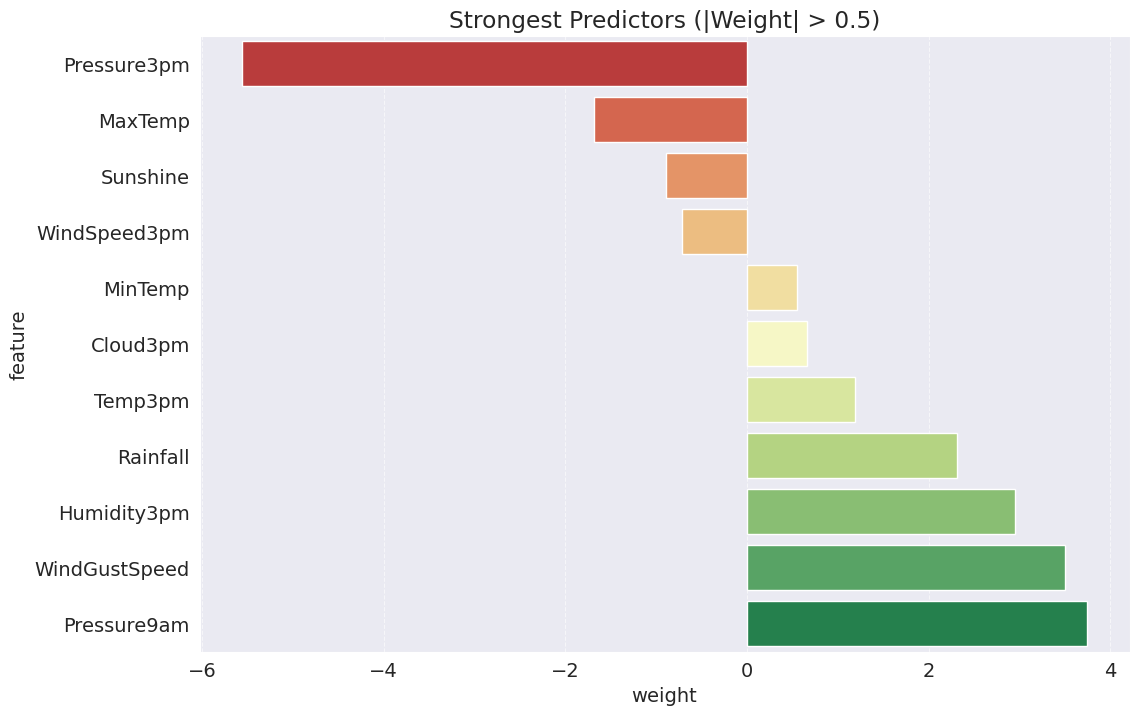

In [958]:
#Starting the process of training and choosing the right model
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=150,class_weight='balanced',random_state=42,solver='liblinear')
train_inputs = train_df[input_columns]
val_inputs = val_df[input_columns]
test_inputs = test_df[input_columns]


model.fit(train_df,train_targets)

train_pred = model.predict(train_inputs)
val_pred = model.predict(val_inputs)
test_pred = model.predict(test_inputs)

features = scaler.get_feature_names_out()
weights = model.coef_[0] 

weighted_train_columns = pd.DataFrame({'feature': features, 'weight': weights})

mask = weighted_train_columns['weight'].between(-0.5, 0.5)
columns_to_be_removed = weighted_train_columns[mask]
rows_to_be_removed = columns_to_be_removed.index

to_drop = columns_to_be_removed['feature'].tolist()
train_df = train_df.drop(columns=to_drop)
val_df = val_df.drop(columns=to_drop)
test_df = test_df.drop(columns=to_drop)

weighted_train_columns = weighted_train_columns.drop(index=rows_to_be_removed)

plt.figure(figsize=(12, 8))
sns.barplot(data=weighted_train_columns.sort_values(by='weight'), x='weight', y='feature', palette='RdYlGn')
plt.title('Strongest Predictors (|Weight| > 0.5)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [959]:
#Testing the results & scores
from sklearn.metrics import accuracy_score
train_probs = model.predict_proba(train_inputs)
print(f"accuracy score:- {accuracy_score(train_targets,train_pred)}",f"\nmodel class:-{model.classes_}",f"\nprobabilities:- {train_probs}")


accuracy score:- 0.7993325713352656 
model class:-['No' 'Yes'] 
probabilities:- [[0.81740196 0.18259804]
 [0.81381831 0.18618169]
 [0.88975821 0.11024179]
 ...
 [0.95628025 0.04371975]
 [0.93870574 0.06129426]
 [0.61390258 0.38609742]]


In [979]:
# Performing confution metics to test the model in all 4 possible results(Positive(True or False), Negative(True or False))
from sklearn.metrics import confusion_matrix

train_c_m = confusion_matrix(train_targets,train_pred,normalize='true')
val_c_m = confusion_matrix(val_targets,val_pred,normalize='true')
test_c_m = confusion_matrix(test_targets,test_pred,normalize='true')

print(f"Train Confusion matrix: {train_c_m * 100}%\n")
print(f"Validation Confusion Matrix: {val_c_m * 100}\n")
print(f"Test Confusion Matrix: {test_c_m * 100}")



Train Confusion matrix: [[80.33862712 19.66137288]
 [21.48362235 78.51637765]]%

Validation Confusion Matrix: [[83.7021686  16.2978314 ]
 [27.08216881 72.91783119]]

Test Confusion Matrix: [[81.4231833  18.5768167 ]
 [25.93991416 74.06008584]]


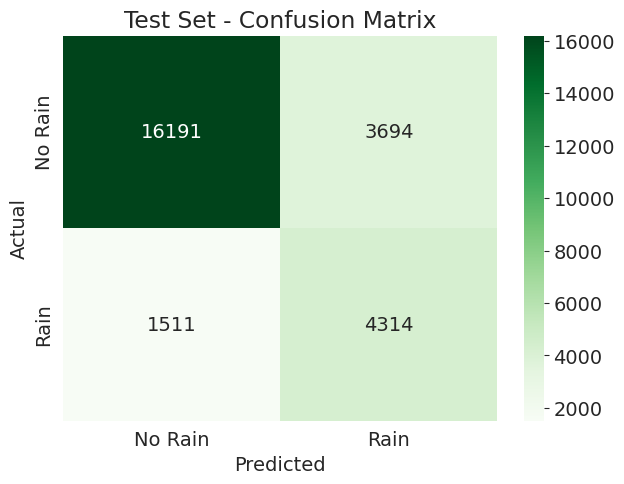

In [961]:
plt.figure(figsize=(7,5))
sns.heatmap(test_c_m, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Rain', 'Rain'], 
            yticklabels=['No Rain', 'Rain'])
plt.title('Test Set - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [962]:
train_score = accuracy_score(train_targets, train_pred)
val_score = accuracy_score(val_targets,val_pred)
test_score = accuracy_score(test_targets, test_pred)


print(f"Train Accuracy: {train_score * 100:.2f}%")
print(f"Validation Accuracy: {val_score * 100:.2f}%")
print(f"Test Accuracy: {test_score * 100:.2f}%")

Train Accuracy: 79.93%
Validation Accuracy: 81.44%
Test Accuracy: 79.75%


In [963]:
from sklearn.metrics import classification_report

print("Final Classification Report (Test Set):")
print(classification_report(test_targets, test_pred))

Final Classification Report (Test Set):


              precision    recall  f1-score   support

          No       0.91      0.81      0.86     19885
         Yes       0.54      0.74      0.62      5825

    accuracy                           0.80     25710
   macro avg       0.73      0.78      0.74     25710
weighted avg       0.83      0.80      0.81     25710

